In [1]:
import os
import joblib
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
best = joblib.load("models/best_price_model.pkl")

In [3]:
df_test = pd.read_csv("database/test_tratado.csv")

In [4]:
y_real = df_test["Preco"]

In [5]:
X_novo = df_test.drop(columns=["Preco"])

In [6]:
pred_best = best.predict(X_novo)

In [7]:
df_test["pred_preco_best"] = pred_best

In [8]:
df_test.head()

,Débitos,Fabricante,Modelo,Ano,Categoria,Couro,Combustivel,Volume_motor,Km,Cilindros,...,Numero_proprietarios,Data_ultima_lavagem,Adesivos_personalizados,Radio_AM_FM,Historico_troca_oleo,Idade,Km_por_ano,Dias_desde_ultima_lavagem,Km_imputado,pred_preco_best
0,0.0,OPEL,Astra,1999,Sedan,Sim,Gasolina,1.6,122231.000000,4,...,3,2022-03-01,Sim,FM,5,24,5092.958333,306,0,6636.310628
1,810.0,VOLKSWAGEN,Jetta,2016,Sedan,Sim,Gasolina,1.8,41000.000000,4,...,3,2022-07-29,Não,AM,6,7,5857.142857,156,0,21852.968583
2,0.0,MERCEDES-BENZ,CLK 230,2004,Cupê,Sim,Gasolina,2.3,328000.000000,4,...,5,2021-05-02,Sim,AM/FM,5,19,17263.157895,609,0,8203.573016
3,1502.0,VOLKSWAGEN,Jetta,2014,Sedan,Sim,Gasolina,1.8,134400.000000,4,...,5,2020-04-11,Não,AM/FM,10,9,14933.333333,995,0,16412.809213
4,0.0,NISSAN,X-Terra,2004,SUV,Nao,Gasolina,3.3,170715.471415,6,...,4,2020-12-03,Sim,AM/FM,5,19,8985.024811,759,1,10868.857706


In [9]:
def calcular_metricas(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [10]:
mae_best, rmse_best, r2_best = calcular_metricas(y_real, pred_best)

print("Best Model")
print("MAE :", mae_best)
print("RMSE:", rmse_best)
print("R²  :", r2_best)

Best Model
MAE : 5639.7778437912075
RMSE: 20754.82312001954
R²  : 0.3810941884722647


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# montar dataframe de comparação
df_plot = pd.DataFrame({
    "Preco_real": y_real,
    "pred_best": pred_best
})

# ordenar pelo preço real
df_plot = df_plot.sort_values("Preco_real").reset_index(drop=True)

# erros
df_plot["erro_best"] = df_plot["Preco_real"] - df_plot["pred_best"]

df_plot["erro_abs_best"] = np.abs(df_plot["erro_best"])

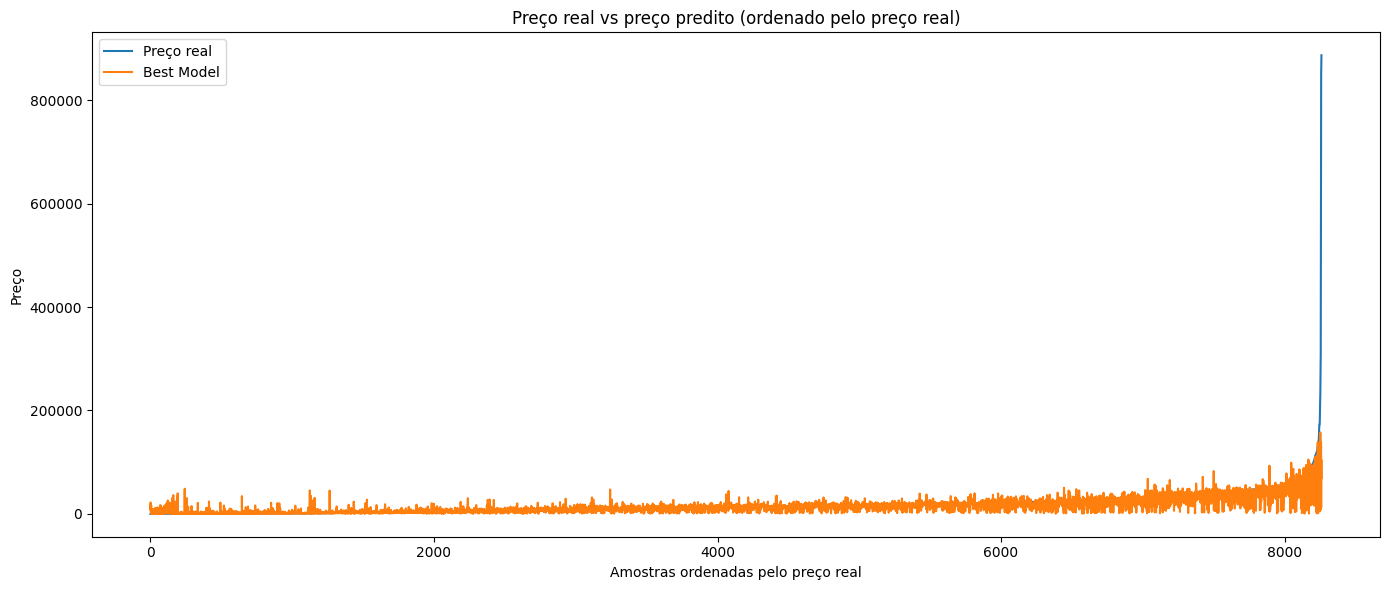

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(df_plot["Preco_real"].values, label="Preço real")
plt.plot(df_plot["pred_best"].values, label="Best Model")
plt.xlabel("Amostras ordenadas pelo preço real")
plt.ylabel("Preço")
plt.title("Preço real vs preço predito (ordenado pelo preço real)")
plt.legend()
plt.tight_layout()
plt.show()

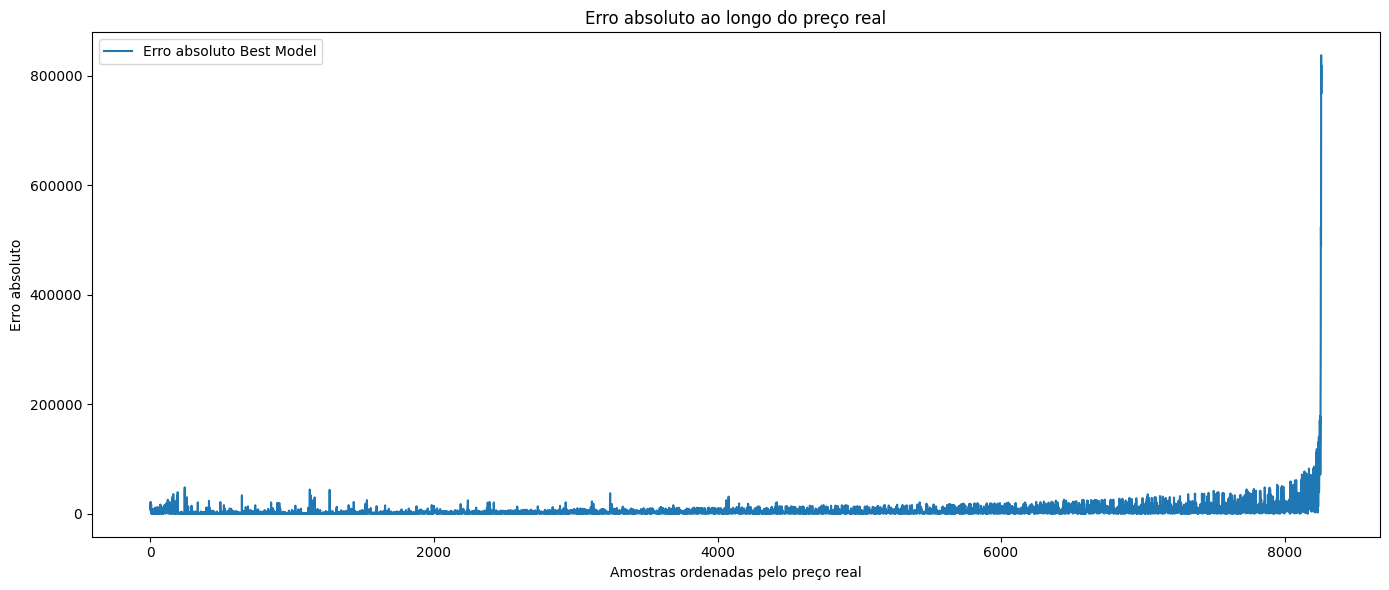

In [13]:
plt.figure(figsize=(14, 6))
plt.plot(df_plot["erro_abs_best"].values, label="Erro absoluto Best Model")
plt.xlabel("Amostras ordenadas pelo preço real")
plt.ylabel("Erro absoluto")
plt.title("Erro absoluto ao longo do preço real")
plt.legend()
plt.tight_layout()
plt.show()